In [1]:
import numpy as np
import torch 
from torch import nn 
from torchvision import datasets
from torchvision.transforms import ToTensor
from dataclasses import dataclass
import random
import matplotlib.pyplot as plt
import time

@dataclass(frozen = True)
class Params: 
    r : float
    R : float
    kappa : float
    vs : float
    a : float
    sig_x : float
    sig_y : float
    X_min : float
    X_max : float
    Y_min : float
    Y_max : float

params = Params(
    r = .5,
    R = np.sqrt(2),
    kappa = .1,
    vs = .5,
    a = .2,
    sig_x = .5,
    sig_y = .2,
    X_min = -2.0,
    X_max = 2.0,
    Y_min = -2.0,
    Y_max = 2.0
)
def vc_field(X, Y, params):
    #XX,YY = np.meshgrid(X,Y)
    s = ((X**2+Y**2) - params.r**2) / (params.R**2 - params.r**2)
    #print (s.shape)
    return 1.0 - params.a * np.sin(np.pi * s)

def f_1(x,y): 
    N = len(x)
    return np.ones(N)

In [2]:
class PINN(nn.Module) : 
    def __init__(self, hidden_size = 64, n_layers = 4): 
        super().__init__()
        layers = [nn.Linear(2,hidden_size), nn.Tanh()]
        for _ in range(n_layers-1):
            layers += [nn.Linear(hidden_size, hidden_size), nn.Tanh()]
        layers += [nn.Linear(hidden_size, 1)]

        self.network = nn.Sequential(*layers)

    def forward(self,x):
        return self.network(x)

model = PINN(hidden_size = 64, n_layers = 4)

def derivatives_pinn(model, X): 
    X.requires_grad_(True)
    #print(X.shape)
    u = model(X)
    #print(u.shape)
    grads = torch.autograd.grad(u.sum(), X, create_graph = True)[0]
    ux = grads[:, 0:1]
    uy = grads[:, 1:2]

    uxx = torch.autograd.grad(ux.sum(), X, create_graph=True)[0][:, 0:1]

    uyy = torch.autograd.grad(uy.sum(), X, create_graph=True)[0][:, 1:2]

    return u, ux, uy, uxx, uyy


In [3]:
def loss_pde(model, xy_colloc, f_vals, vc_valls, params): 
    u, ux, uy, uxx, uyy = derivatives_pinn(model, xy_colloc)
    #print("ux   :", ux.shape)
    #print("uxx  :", uxx.shape)
    #print("vc   :", vc_valls.shape)
    #print("f    :", f_vals.shape)

    
    grad_norm_2 = torch.sqrt(ux**2 + uy**2)
    grad_norm_1 = torch.abs(ux) + torch.abs(uy)
    F = -.5*(params.sig_x**2 * uxx + params.sig_y**2 * uyy) - vc_valls * ux 
    F+= params.vs * grad_norm_2 - params.kappa * grad_norm_1 - f_vals

    return F.pow(2).mean()

def loss_inner(model, xy_inner): 
    u, ux, uy, uxx, uyy = derivatives_pinn(model, xy_inner)
    ## pénalisation en norme 2, u = 0 au centre
    norm_u = u.pow(2).mean()

    return norm_u

def loss_outer(model, xy_outer):
    u = model(xy_outer)
    ## pénalisation en norme 2, u = 1 a l'exterieur
    norm_u = (u-1).pow(2).mean()
    return norm_u

In [4]:
def sample_collocation(N, params):
    """
    Tire N points uniformes dans l'anneau r < ||x|| < R par rejet.
    """
    pts = []
    while len(pts) < N:
        # Tirer dans le carré [-R, R]²
        xy = np.random.uniform(-params.R, params.R, size=(N * 4, 2))
        rad = np.sqrt(xy[:, 0]**2 + xy[:, 1]**2)
        mask = (rad > params.r) & (rad < params.R)
        pts.append(xy[mask])
    pts = np.concatenate(pts, axis=0)[:N]
    return torch.tensor(pts, dtype=torch.float32)


def sample_boundary(N, params):
    """
    Tire N points sur ∂Br (bord intérieur) et N points sur ∂BR (bord extérieur).
    """
    theta = np.random.uniform(0, 2 * np.pi, size=N)

    # Bord intérieur : rayon r
    xy_inner = np.stack([params.r * np.cos(theta),
                         params.r * np.sin(theta)], axis=1)

    # Bord extérieur : rayon R
    xy_outer = np.stack([params.R * np.cos(theta),
                         params.R * np.sin(theta)], axis=1)

    return (torch.tensor(xy_inner, dtype=torch.float32),
            torch.tensor(xy_outer, dtype=torch.float32))
    

In [ ]:
def train(model, params,vc, f, N_colloc = 1000, N_bord = 100, n_epochs = 1000, lam = 50, lr = 1e-3): 
    optimizer = torch.optim.Adam(model.parameters(), lr = lr)
    losses = []
    Time = 0
    for epoch in range(n_epochs):
        t0 = time.time()
        xy_colloc = sample_collocation(N_colloc, params)
        xy_inner, xy_outer = sample_boundary(N_bord, params)
        
        XX = xy_colloc[:, 0].detach().numpy()
        YY = xy_colloc[:, 1].detach().numpy()
        vc_vals = torch.from_numpy(vc(XX, YY, params)).float().unsqueeze(1)
        #print(vc_vals.shape)
        f_vals  = torch.from_numpy(f(XX, YY)).float().unsqueeze(1) 
        ##Loss du modèle
        l_pde = loss_pde(model, xy_colloc, f_vals, vc_vals, params)
        l_bord = loss_inner(model, xy_inner) + loss_outer(model, xy_outer)
        loss = l_pde + lam*l_bord
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        t1 = time.time()
        losses.append(loss.item())
        Time += (t1-t0)
        if epoch % 50 == 0: 
            print(f"epoch {epoch: 5d}|loss = {loss.item():.3e} | time = {Time}")
    return losses, Time

In [6]:
losses = train(model, params, vc_field, f_1)

epoch     0|loss = 4.951e+01 | time = 0.017532825469970703
epoch    50|loss = 9.781e+00 | time = 0.25078892707824707
epoch   100|loss = 1.167e+00 | time = 0.48326992988586426
epoch   150|loss = 9.617e-01 | time = 0.7164225578308105
epoch   200|loss = 8.712e-01 | time = 0.9487025737762451
epoch   250|loss = 9.820e-01 | time = 1.1857538223266602
epoch   300|loss = 9.805e-01 | time = 1.4280829429626465
epoch   350|loss = 8.719e-01 | time = 1.6612141132354736
epoch   400|loss = 9.328e-01 | time = 1.8977649211883545
epoch   450|loss = 9.257e-01 | time = 2.131897449493408
epoch   500|loss = 8.738e-01 | time = 2.3720388412475586
epoch   550|loss = 9.073e-01 | time = 2.607117176055908
epoch   600|loss = 8.514e-01 | time = 2.841596841812134
epoch   650|loss = 8.366e-01 | time = 3.076112747192383
epoch   700|loss = 8.905e-01 | time = 3.3110368251800537
epoch   750|loss = 8.781e-01 | time = 3.5448453426361084
epoch   800|loss = 8.493e-01 | time = 3.779259443283081
epoch   850|loss = 8.216e-01 | t

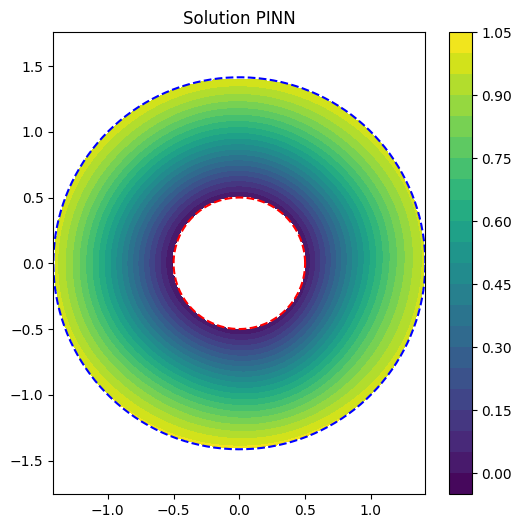

In [7]:
# Grille d'évaluation
N_plot = 200
x = np.linspace(-params.R, params.R, N_plot)
y = np.linspace(-params.R, params.R, N_plot)
XX, YY = np.meshgrid(x, y)

# Évaluation du modèle sur la grille
xy_grid = np.stack([XX.ravel(), YY.ravel()], axis=1)
with torch.no_grad():
    U = model(torch.tensor(xy_grid, dtype=torch.float32)).numpy().reshape(N_plot, N_plot)

# Masque anneau
rad = np.sqrt(XX**2 + YY**2)
mask = (rad > params.r) & (rad < params.R)
U[~mask] = np.nan

# Plot
theta = np.linspace(0, 2*np.pi, 300)
plt.figure(figsize=(6, 6))
plt.contourf(XX, YY, U, 20, cmap='viridis')
plt.colorbar()
plt.plot(params.r*np.cos(theta), params.r*np.sin(theta), 'r--', lw=1.5)
plt.plot(params.R*np.cos(theta), params.R*np.sin(theta), 'b--', lw=1.5)
plt.axis('equal')
plt.title('Solution PINN')
plt.show()

## Avec sol exacte disponible

In [8]:
def compute_f_exact(XX, YY, hx=1e-5, hy=1e-5):
    """
    Calcul numérique du second membre f tel que u_exact soit solution de l'EDP.
    On évalue F(x, u, ∇u, D²u) avec les dérivées analytiques de u_exact.
   """
    phi = (XX**2 + YY**2 - params.r**2) / (params.R**2 - params.r**2)
    c   = 0.5 * np.pi / (params.R**2 - params.r**2)
    # Dérivées de uex = sin(pi/2 * phi)
    ux  =  c * np.cos(0.5*np.pi*phi) * 2*XX
    uy  =  c * np.cos(0.5*np.pi*phi) * 2*YY
    uxx = -c**2 * np.sin(0.5*np.pi*phi) * (2*XX)**2 + c * np.cos(0.5*np.pi*phi) * 2
    uyy = -c**2 * np.sin(0.5*np.pi*phi) * (2*YY)**2 + c * np.cos(0.5*np.pi*phi) * 2

    norm2 = np.sqrt(ux**2 + uy**2)
    norm1 = np.abs(ux) + np.abs(uy)

    VC = 1 - params.a * np.sin(np.pi * phi)

    # f = -1/2 σx² uxx - 1/2 σy² uyy - vc*ux + vs*||∇u||_2 - κ*||∇u||_1
    f = (- 0.5*params.sig_x**2 * uxx
         - 0.5*params.sig_y**2 * uyy
         - VC * ux
         + params.vs * norm2
         - params.kappa * norm1)
    return f

In [9]:
model_ex = PINN()
train(model_ex, params, vc_field, compute_f_exact)

epoch     0|loss = 5.863e+01 | time = 0.005470752716064453
epoch    50|loss = 1.640e+01 | time = 0.24474120140075684
epoch   100|loss = 2.985e-01 | time = 0.4822373390197754
epoch   150|loss = 1.280e-01 | time = 0.7198243141174316
epoch   200|loss = 8.464e-02 | time = 0.9561176300048828
epoch   250|loss = 7.307e-02 | time = 1.1931419372558594
epoch   300|loss = 9.775e-02 | time = 1.4298710823059082
epoch   350|loss = 7.107e-02 | time = 1.6669530868530273
epoch   400|loss = 7.467e-02 | time = 1.9041681289672852
epoch   450|loss = 9.662e-02 | time = 2.14121413230896
epoch   500|loss = 5.536e-02 | time = 2.3776299953460693
epoch   550|loss = 6.815e-02 | time = 2.614102840423584
epoch   600|loss = 9.024e-02 | time = 2.8512704372406006
epoch   650|loss = 6.474e-02 | time = 3.0883331298828125
epoch   700|loss = 1.004e-01 | time = 3.325521230697632
epoch   750|loss = 5.534e-02 | time = 3.562790870666504
epoch   800|loss = 5.172e-02 | time = 3.800607442855835
epoch   850|loss = 6.972e-02 | tim

([58.631595611572266,
  50.50844955444336,
  45.04108428955078,
  40.573463439941406,
  35.80352020263672,
  32.09084701538086,
  30.454410552978516,
  29.38674545288086,
  29.780797958374023,
  30.545394897460938,
  31.225765228271484,
  31.2970027923584,
  30.857881546020508,
  30.010488510131836,
  29.172693252563477,
  28.272701263427734,
  27.775671005249023,
  27.493854522705078,
  27.589365005493164,
  27.926103591918945,
  27.642879486083984,
  27.882862091064453,
  27.717622756958008,
  27.2767391204834,
  27.036121368408203,
  26.5046443939209,
  26.268672943115234,
  25.944965362548828,
  25.756589889526367,
  25.75996971130371,
  25.555513381958008,
  25.416269302368164,
  25.228988647460938,
  24.800392150878906,
  24.619184494018555,
  24.091880798339844,
  23.87714195251465,
  23.605470657348633,
  23.264869689941406,
  22.722915649414062,
  22.784324645996094,
  22.085811614990234,
  21.690052032470703,
  21.292789459228516,
  21.1630916595459,
  19.942058563232422,
  1

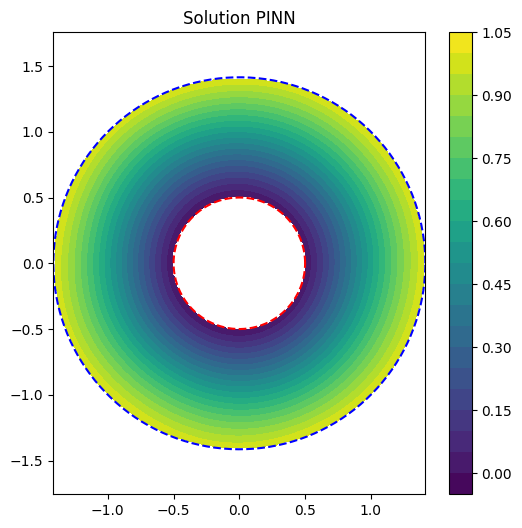

In [10]:
# Grille d'évaluation
N_plot = 200
x = np.linspace(-params.R, params.R, N_plot)
y = np.linspace(-params.R, params.R, N_plot)
XX, YY = np.meshgrid(x, y)

# Évaluation du modèle sur la grille
xy_grid = np.stack([XX.ravel(), YY.ravel()], axis=1)
with torch.no_grad():
    U = model_ex(torch.tensor(xy_grid, dtype=torch.float32)).numpy().reshape(N_plot, N_plot)

# Masque anneau
rad = np.sqrt(XX**2 + YY**2)
mask = (rad > params.r) & (rad < params.R)
U[~mask] = np.nan

# Plot
theta = np.linspace(0, 2*np.pi, 300)
plt.figure(figsize=(6, 6))
plt.contourf(XX, YY, U, 20, cmap='viridis')
plt.colorbar()
plt.plot(params.r*np.cos(theta), params.r*np.sin(theta), 'r--', lw=1.5)
plt.plot(params.R*np.cos(theta), params.R*np.sin(theta), 'b--', lw=1.5)
plt.axis('equal')
plt.title('Solution PINN')
plt.show()